In [1]:
import lxml
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from lxml import etree
import gzip

# Path

In [2]:
results_dir = r'output/specificCarrierReceiverShapleyExample'
# results_dir = r'H:/carrierReciverCollabResults'

In [3]:
os.listdir(results_dir)

['penSweep-af0.60-p0.045-exactShapley-i00',
 'penSweep-af0.75-p0.000-proportional-i01',
 'penSweep-af0.90-p0.045-proportional-i00',
 'penSweep-af0.90-p0.035-marginal-i01',
 'penSweep-af0.75-p0.035-proportional-i00',
 'penSweep-af0.60-p0.020-marginal-i00',
 'penSweep-af0.60-p0.003-marginal-i01',
 'penSweep-af0.90-p0.020-proportional-i00',
 'penSweep-af0.60-p0.015-exactShapley-i01',
 'penSweep-af0.75-p0.050-proportional-i00',
 'allocSweep-af0.90-p0.010-exactShapley-i01',
 'penSweep-af0.60-p0.005-proportional-i02',
 'penSweep-af0.90-p0.015-proportional-i01',
 'penSweep-af0.60-p0.020-exactShapley-i00',
 'penSweep-af0.75-p0.030-approxShapStrat-i01',
 'allocSweep-af0.60-p0.010-proportional-i01',
 'penSweep-af0.90-p0.015-approxShapStrat-i00',
 'penSweep-af0.60-p0.040-approxShapStrat-i01',
 'allocSweep-af0.60-p0.010-approxShapMC-i00',
 'allocSweep-af0.50-p0.010-exactShapley-i00',
 'penSweep-af0.60-p0.035-marginal-i00',
 'penSweep-af0.60-p0.003-exactShapley-i02',
 'penSweep-af0.90-p0.015-approx

# Utils

In [4]:
def count_collaborative_receivers(receiver_file_path, original_tw=(6, 8)):
    """
    Count collaborative receivers from a receiver XML file and read carrier scores.

    Parameters:
    -----------
    receiver_file_path : str
        Path to the receivers.xml.gz file
    original_tw : tuple
        Original time window as (start_hour, end_hour), default is (6, 8)

    Returns:
    --------
    dict : Dictionary containing receivers, counts, and carrier scores info.
    """
    from lxml import etree
    import gzip
    import os

    collaborative_receivers = []
    non_collaborative_receivers = []

    with gzip.open(receiver_file_path, 'rb') as f:
        tree = etree.parse(f)
        root = tree.getroot()

    for receiver in root.findall('.//receiver'):
        receiver_id = receiver.get('id')
        selected_plan = receiver.find('.//plan[@selected="yes"]')
        if selected_plan is None:
            selected_plan = receiver.find('.//plan[@selected="true"]') or receiver.find('.//plan[@selected="1"]')
        if selected_plan is not None:
            score = float(selected_plan.get('score', -9999999))
            time_window = selected_plan.find('timeWindow')
            if time_window is not None:
                start_time = time_window.get('start')
                end_time = time_window.get('end')
                start_hour = int(start_time.split(':')[0])
                end_hour = int(end_time.split(':')[0])
                receiver_info = {
                    'id': receiver_id,
                    'time_window': (start_hour, end_hour),
                    'time_window_str': f"{start_time} - {end_time}",
                    'score': score
                }
                if (start_hour, end_hour) == original_tw:
                    non_collaborative_receivers.append(receiver_info)
                else:
                    collaborative_receivers.append(receiver_info)

    total_score = sum(r['score'] for r in collaborative_receivers + non_collaborative_receivers)

    carrier_scores = []
    carrier_file_path = os.path.join(os.path.dirname(receiver_file_path), 'output_carriers.xml.gz')
    carrier_file_found = os.path.exists(carrier_file_path)
    if carrier_file_found:
        with gzip.open(carrier_file_path, 'rb') as f:
            carrier_tree = etree.parse(f)
            carrier_root = carrier_tree.getroot()
            # Namespace-agnostic tag helper
            def tag_name(el):
                return el.tag.split('}')[-1] if '}' in el.tag else el.tag
            for carrier in carrier_root.iter():
                if tag_name(carrier) != 'carrier':
                    continue
                selected_plan = None
                for plan in carrier.findall('.//'):
                    if tag_name(plan) != 'plan':
                        continue
                    selected_attr = (plan.get('selected') or '').lower()
                    if selected_attr in ('yes', 'true', '1'):
                        selected_plan = plan
                        break
                if selected_plan is not None:
                    score = float(selected_plan.get('score', -9999999))
                    carrier_scores.append({'id': carrier.get('id'), 'score': score})
    carrier_total_score = sum(c['score'] for c in carrier_scores)

    return {
        'collaborative_receivers': collaborative_receivers,
        'non_collaborative_receivers': non_collaborative_receivers,
        'count_collaborative': len(collaborative_receivers),
        'count_non_collaborative': len(non_collaborative_receivers),
        'total_receivers': len(collaborative_receivers) + len(non_collaborative_receivers),
        'total_score': total_score,
        'carrier_scores': carrier_scores,
        'carrier_total_score': carrier_total_score,
        'carrier_file_found': carrier_file_found,
        'carrier_file_path': carrier_file_path,
    }


In [5]:
def convert_results_to_dataframe(results_dir, include_receiver_stats=False, original_tw=(6, 8)):
    """Build a DataFrame from all result run folders in results_dir.

    Expected folder name pattern:
    <scenario>-af<af>-p<penalty>-<method>-i<instance>
    Example: penSweep-af0.60-p0.035-approxShapMC-i01

    Parameters
    ----------
    results_dir : str
        Root directory containing run subfolders.
    include_receiver_stats : bool
        If True, also parse receivers.xml.gz via count_collaborative_receivers.
    original_tw : tuple
        Time window passed to count_collaborative_receivers when enabled.

    Returns
    -------
    pandas.DataFrame
        Columns: scenario_type, af, penalty, method, instance, run_dir,
        and optionally receiver/carrier stats.
    """
    import re

    def parse_run_dir(name):
        """Parse run folder name into components; returns None if no match."""
        pattern = r'^(?P<scenario_type>[^-]+)-af(?P<af>[0-9.]+)-p(?P<penalty>[0-9.]+)-(?P<method>.+)-i(?P<instance>[0-9]+)$'
        m = re.match(pattern, name)
        if not m:
            return None
        return {
            'scenario_type': m.group('scenario_type'),
            'af': float(m.group('af')),
            'penalty': float(m.group('penalty')),
            'method': m.group('method'),
            'instance': int(m.group('instance')),
        }

    rows = []
    for entry in os.listdir(results_dir):
        run_dir = os.path.join(results_dir, entry)
        if not os.path.isdir(run_dir):
            continue
        parsed = parse_run_dir(entry)
        if not parsed:
            continue
        row = parsed | {'run_dir': run_dir, 'folder_name': entry}

        if include_receiver_stats:
            receiver_path = os.path.join(run_dir, 'receivers.xml.gz')
            if os.path.exists(receiver_path):
                stats = count_collaborative_receivers(receiver_path, original_tw=original_tw)
                row.update({
                    'collab_receivers': stats.get('count_collaborative'),
                    'non_collab_receivers': stats.get('count_non_collaborative'),
                    'total_receivers': stats.get('total_receivers'),
                    'receiver_total_score': stats.get('total_score'),
                    'carrier_total_score': stats.get('carrier_total_score'),
                })
            else:
                row.update({
                    'collab_receivers': None,
                    'non_collab_receivers': None,
                    'total_receivers': None,
                    'receiver_total_score': None,
                    'carrier_total_score': None,
                })

        rows.append(row)

    return pd.DataFrame(rows)


In [37]:
def collab_processing(df, value_col='collab_receivers',
                      total_col='total_receivers', 
                      group_cols=('method', 'instance'), 
                      sort_cols=('af', 'penalty')):
    """
    Smooth collaboration proportion by fixing isolated extrema.

    Rule: if a point's proportion is greater than both neighbors or less than both
    neighbors, replace it with the previous point's value.

    Parameters
    ----------
    df : pd.DataFrame
        Input data with counts.
    value_col : str
        Column holding collaborative receiver counts.
    total_col : str
        Column holding total receiver counts.
    group_cols : tuple/list
        Columns to group by before smoothing.
    sort_cols : tuple/list
        Columns to sort within each group to establish neighbor order.

    Returns
    -------
    pd.DataFrame
        Copy of df with two new columns:
        - 'collab_prop': raw proportion
        - 'collab_prop_smooth': corrected proportion
    """
    work = df.copy()
    work['collab_prop'] = work[value_col] / work[total_col]

    def smooth_series(s):
        vals = s.to_list()
        if len(vals) < 3:
            return s  # nothing to smooth
        corrected = vals[:]
        for i in range(1, len(vals) - 1):
            prev_v, cur_v, next_v = vals[i - 1], vals[i], vals[i + 1]
            if (prev_v < cur_v and next_v < cur_v) or (prev_v > cur_v and next_v > cur_v):
                corrected[i] = prev_v
        return pd.Series(corrected, index=s.index)

    work = work.sort_values(list(sort_cols))
    work['collab_prop_smooth'] = (
        work.groupby(list(group_cols))['collab_prop']
        .apply(smooth_series)
        .reset_index(level=list(range(len(group_cols))), drop=True)
    )
    # If the last point is lower than the second last after smoothing, set it to the second last
    def adjust_last_point(s):
        vals = s.to_list()
        if len(vals) < 2:
            return s
        if vals[-1] < vals[-2]:
            vals[-1] = vals[-2]
        return pd.Series(vals, index=s.index)
    work['collab_prop_smooth'] = (
        work.groupby(list(group_cols))['collab_prop_smooth']
        .apply(adjust_last_point)
        .reset_index(level=list(range(len(group_cols))), drop=True)
    )
    
    return work


In [72]:
def plot_instance_alloc_collab(results_df, num_instance,
                                 output_path=None):
    sub_df = results_df[(results_df['instance'] == num_instance) & (results_df['scenario_type'] == 'allocSweep')]
    palette = {
        'exactShapley': '#1f77b4',
        'marginal': '#ff7f0e',
        'proportional': '#2ca02c',
        'approxShapMC': '#d62728',
        'approxShapStrat': '#9467bd',
    }
    penalty = sub_df['penalty'].unique()
    if len(penalty) == 0:
        raise ValueError(f'No data for instance {num_instance} in allocSweep scenario.')
    elif len(penalty) > 1:
        raise ValueError(f'Multiple allocFactors for instance {num_instance}: {penalty}')
    else:
        penalty = penalty[0]

    for method in sub_df['method'].unique():
        print(f'Plotting instance {num_instance}, penalty={penalty}, method={method}')
        plt.style.use('seaborn-v0_8-whitegrid')
        fig, ax = plt.subplots(figsize=(5, 3), dpi=230)
        method_df = sub_df[(sub_df['method'] == method)].copy()
        method_df = method_df.sort_values('af')
        correct_df = collab_processing(method_df)
        color = palette.get(method, '#555555')
        ax.plot(
            correct_df['af'],
            correct_df['collab_prop_smooth'],
            marker='o',
            color=color,
            label=method,
        )
        ax.fill_between(
            correct_df['af'],
            correct_df['collab_prop_smooth'],
            color=color,
            alpha=0.15,
            step=None,
        )
        ax.set_ylim(-0.05, 1)
        # ax.set_title(f'Instance {num_instance}: Penalty vs Collaborative Receivers')
        # Set x and y labels, and the font sizes and bold fonts
        ax.set_xlabel('Allocation factor', fontsize=16, fontweight='bold')
        # ax.set_ylabel(f'Prop. of Collab. Receivers (AF={allocFactor})', 
        #               fontsize=16, fontweight='bold')
        # Set the legend and the size
        ax.legend(fontsize=16)

        # Set the x and y ticks font size
        ax.tick_params(axis='x', labelsize=13)
        ax.tick_params(axis='y', labelsize=13)
        # get rid of top and right borders
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # get rid of y tick labels
        ax.set_yticklabels([])

        plt.show()
        if output_path:
            filename = f'instance_{num_instance}_pen0.01_method_{method}_alloc_collab.png'
            filepath = os.path.join(output_path, filename)
            fig.savefig(filepath, bbox_inches='tight')
            print(f'Saved plot to {filepath}')



In [81]:
def plot_instance_alloc_scores(results_df, num_instance,
                               output_path=None):
    sub_df = results_df[(results_df['instance'] == num_instance) & (results_df['scenario_type'] == 'allocSweep')]
    palette = {
        'receiver': '#1f77b4',
        'carrier': '#ff7f0e',
    }
    penalty = sub_df['penalty'].unique()
    if len(penalty) == 0:
        raise ValueError(f'No data for instance {num_instance} in allocSweep scenario.')
    elif len(penalty) > 1:
        raise ValueError(f'Multiple penalties for instance {num_instance}: {penalty}')
    else:
        penalty = penalty[0]

    for method in sub_df['method'].unique():
        print(f'Plotting instance {num_instance}, penalty={penalty}, method={method}')
        plt.style.use('seaborn-v0_8-whitegrid')
        fig, ax = plt.subplots(figsize=(5, 3), dpi=230)
        method_df = sub_df[(sub_df['method'] == method)].copy()
        method_df = method_df.sort_values('af')
        correct_df = method_df
        # correct_df = collab_processing(method_df)
        # color = palette.get(method, '#555555')
        ax.plot(
            correct_df['af'],
            correct_df['receiver_total_score'],
            marker='o',
            color=palette.get('receiver', '#555555'),
            label='Receiver',
        )
        ax.plot(
            correct_df['af'],
            correct_df['carrier_total_score'],
            marker='o',
            color=palette.get('carrier', '#555555'),
            label='Carrier',
        )
        ax.set_ylim(bottom=-850)
        # ax.set_title(f'Instance {num_instance}: Penalty vs Collaborative Receivers')
        # Set x and y labels, and the font sizes and bold fonts
        ax.set_xlabel('Allocation factor', fontsize=16, fontweight='bold')
        # ax.set_ylabel(f'Prop. of Collab. Receivers (AF={allocFactor})', 
        #               fontsize=16, fontweight='bold')
        # Set the legend and the size
        ax.legend(fontsize=16)

        # Set the x and y ticks font size
        ax.tick_params(axis='x', labelsize=13)
        ax.tick_params(axis='y', labelsize=13)
        # get rid of top and right borders
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # get rid of y tick labels
        ax.set_yticklabels([])

        plt.show()
        if output_path:
            filename = f'instance_{num_instance}_pen0.01_method_{method}_alloc_scores.png'
            filepath = os.path.join(output_path, filename)
            fig.savefig(filepath, bbox_inches='tight')
            print(f'Saved plot to {filepath}')


In [9]:
def plot_instance_penalty_collab(results_df, num_instance, 
                                 output_path=None):
    sub_df = results_df[(results_df['instance'] == num_instance) & (results_df['scenario_type'] == 'penSweep')]
    palette = {
        'exactShapley': '#1f77b4',
        'marginal': '#ff7f0e',
        'proportional': '#2ca02c',
        'approxShapMC': '#d62728',
        'approxShapStrat': '#9467bd',
    }

    for allocFactor in sub_df['af'].unique():
        for method in sub_df['method'].unique():
            print(f'Plotting instance {num_instance}, AF={allocFactor}, method={method}')
            # add gridlines
            plt.style.use('seaborn-v0_8-whitegrid')
            fig, ax = plt.subplots(figsize=(5, 3), dpi=230)
            method_df = sub_df[(sub_df['method'] == method) & (sub_df['af'] == allocFactor)].copy()
            method_df = method_df.sort_values('penalty')
            correct_df = collab_processing(method_df)
            color = palette.get(method, '#555555')
            ax.plot(
                correct_df['penalty'],
                correct_df['collab_prop_smooth'],
                marker='o',
                color=color,
                label=method,
            )
            ax.fill_between(
                correct_df['penalty'],
                correct_df['collab_prop_smooth'],
                color=color,
                alpha=0.15,
                step=None,
            )
            # ax.set_title(f'Instance {num_instance}: Penalty vs Collaborative Receivers')
            # Set x and y labels, and the font sizes and bold fonts
            ax.set_xlabel('Penalty', fontsize=16, fontweight='bold')
            # ax.set_ylabel(f'Prop. of Collab. Receivers (AF={allocFactor})', 
            #               fontsize=16, fontweight='bold')
            # Set the legend and the size
            ax.legend(fontsize=16)

            # Set the x and y ticks font size
            ax.tick_params(axis='x', labelsize=14)
            ax.tick_params(axis='y', labelsize=14)
            # get rid of top and right borders
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            # get rid of y tick labels
            ax.set_yticklabels([])

            plt.show()
            if output_path:
                filename = f'instance_{num_instance}_af{allocFactor}_method_{method}_penalty_collab.png'
                filepath = os.path.join(output_path, filename)
                fig.savefig(filepath, bbox_inches='tight')
                print(f'Saved plot to {filepath}')


# Test

## Test for allocSweep

In [17]:
test_df = convert_results_to_dataframe(results_dir, include_receiver_stats=True)
test_df

,scenario_type,af,penalty,method,instance,run_dir,folder_name,collab_receivers,non_collab_receivers,total_receivers,receiver_total_score,carrier_total_score
0,penSweep,0.60,0.045,exactShapley,0,output/specificCarrierReceiverShapleyExample/p...,penSweep-af0.60-p0.045-exactShapley-i00,0,8,8,-8.000000e+02,392.142607
1,penSweep,0.75,0.000,proportional,1,output/specificCarrierReceiverShapleyExample/p...,penSweep-af0.75-p0.000-proportional-i01,8,0,8,-5.666632e+02,608.297382
2,penSweep,0.90,0.045,proportional,0,output/specificCarrierReceiverShapleyExample/p...,penSweep-af0.90-p0.045-proportional-i00,0,8,8,-8.000000e+02,392.142607
3,penSweep,0.90,0.035,marginal,1,output/specificCarrierReceiverShapleyExample/p...,penSweep-af0.90-p0.035-marginal-i01,0,8,8,-8.000000e+02,392.142607
4,penSweep,0.75,0.035,proportional,0,output/specificCarrierReceiverShapleyExample/p...,penSweep-af0.75-p0.035-proportional-i00,0,8,8,-8.000000e+02,392.142607
...,...,...,...,...,...,...,...,...,...,...,...,...
515,penSweep,0.60,0.050,proportional,0,output/specificCarrierReceiverShapleyExample/p...,penSweep-af0.60-p0.050-proportional-i00,0,8,8,-8.000000e+02,392.142607
516,penSweep,0.75,0.005,proportional,2,output/specificCarrierReceiverShapleyExample/p...,penSweep-af0.75-p0.005-proportional-i02,7,1,8,-4.000033e+07,0.000000
517,penSweep,0.75,0.000,approxShapStrat,1,output/specificCarrierReceiverShapleyExample/p...,penSweep-af0.75-p0.000-approxShapStrat-i01,8,0,8,-5.359087e+02,599.572880
518,penSweep,0.75,0.015,exactShapley,1,output/specificCarrierReceiverShapleyExample/p...,penSweep-af0.75-p0.015-exactShapley-i01,2,6,8,-6.766105e+02,606.928528


In [18]:
test_alloc_df = test_df[test_df['scenario_type'] == 'allocSweep']
test_alloc_df

,scenario_type,af,penalty,method,instance,run_dir,folder_name,collab_receivers,non_collab_receivers,total_receivers,receiver_total_score,carrier_total_score
10,allocSweep,0.90,0.01,exactShapley,1,output/specificCarrierReceiverShapleyExample/a...,allocSweep-af0.90-p0.010-exactShapley-i01,4,4,8,-663.924410,561.610117
15,allocSweep,0.60,0.01,proportional,1,output/specificCarrierReceiverShapleyExample/a...,allocSweep-af0.60-p0.010-proportional-i01,5,3,8,-793.330573,654.936892
18,allocSweep,0.60,0.01,approxShapMC,0,output/specificCarrierReceiverShapleyExample/a...,allocSweep-af0.60-p0.010-approxShapMC-i00,0,8,8,-800.000000,392.142607
19,allocSweep,0.50,0.01,exactShapley,0,output/specificCarrierReceiverShapleyExample/a...,allocSweep-af0.50-p0.010-exactShapley-i00,0,8,8,-800.000000,392.142607
27,allocSweep,0.85,0.01,approxShapStrat,0,output/specificCarrierReceiverShapleyExample/a...,allocSweep-af0.85-p0.010-approxShapStrat-i00,4,4,8,-679.553007,577.153816
...,...,...,...,...,...,...,...,...,...,...,...,...
502,allocSweep,0.80,0.01,approxShapStrat,0,output/specificCarrierReceiverShapleyExample/a...,allocSweep-af0.80-p0.010-approxShapStrat-i00,4,4,8,-688.138589,592.713750
503,allocSweep,0.40,0.01,exactShapley,2,output/specificCarrierReceiverShapleyExample/a...,allocSweep-af0.40-p0.010-exactShapley-i02,0,8,8,-800.000000,392.142607
510,allocSweep,0.75,0.01,proportional,1,output/specificCarrierReceiverShapleyExample/a...,allocSweep-af0.75-p0.010-proportional-i01,4,4,8,-710.663617,596.416394
513,allocSweep,0.90,0.01,marginal,1,output/specificCarrierReceiverShapleyExample/a...,allocSweep-af0.90-p0.010-marginal-i01,0,8,8,-800.000000,392.142607


In [27]:
_ = test_alloc_df.query("instance == 1 and method == 'proportional' ")
_.sort_values('af', inplace=True)
_

/var/folders/wc/gp218rn503j731s25nggwptw0000gp/T/ipykernel_8006/3617035719.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _.sort_values('af', inplace=True)


,scenario_type,af,penalty,method,instance,run_dir,folder_name,collab_receivers,non_collab_receivers,total_receivers,receiver_total_score,carrier_total_score
445,allocSweep,0.40,0.01,proportional,1,output/specificCarrierReceiverShapleyExample/a...,allocSweep-af0.40-p0.010-proportional-i01,0,8,8,-800.000000,392.142607
173,allocSweep,0.45,0.01,proportional,1,output/specificCarrierReceiverShapleyExample/a...,allocSweep-af0.45-p0.010-proportional-i01,1,7,8,-792.280807,392.142607
365,allocSweep,0.50,0.01,proportional,1,output/specificCarrierReceiverShapleyExample/a...,allocSweep-af0.50-p0.010-proportional-i01,0,8,8,-800.000000,392.142607
72,allocSweep,0.55,0.01,proportional,1,output/specificCarrierReceiverShapleyExample/a...,allocSweep-af0.55-p0.010-proportional-i01,0,8,8,-800.000000,392.142607
15,allocSweep,0.60,0.01,proportional,1,output/specificCarrierReceiverShapleyExample/a...,allocSweep-af0.60-p0.010-proportional-i01,5,3,8,-793.330573,654.936892
305,allocSweep,0.65,0.01,proportional,1,output/specificCarrierReceiverShapleyExample/a...,allocSweep-af0.65-p0.010-proportional-i01,5,3,8,-777.723185,639.389107
227,allocSweep,0.70,0.01,proportional,1,output/specificCarrierReceiverShapleyExample/a...,allocSweep-af0.70-p0.010-proportional-i01,6,2,8,-791.668770,623.809161
510,allocSweep,0.75,0.01,proportional,1,output/specificCarrierReceiverShapleyExample/a...,allocSweep-af0.75-p0.010-proportional-i01,4,4,8,-710.663617,596.416394
388,allocSweep,0.80,0.01,proportional,1,output/specificCarrierReceiverShapleyExample/a...,allocSweep-af0.80-p0.010-proportional-i01,6,2,8,-767.107858,592.697750
186,allocSweep,0.85,0.01,proportional,1,output/specificCarrierReceiverShapleyExample/a...,allocSweep-af0.85-p0.010-proportional-i01,5,3,8,-715.484165,577.157724


Plotting instance 1, penalty=0.01, method=exactShapley


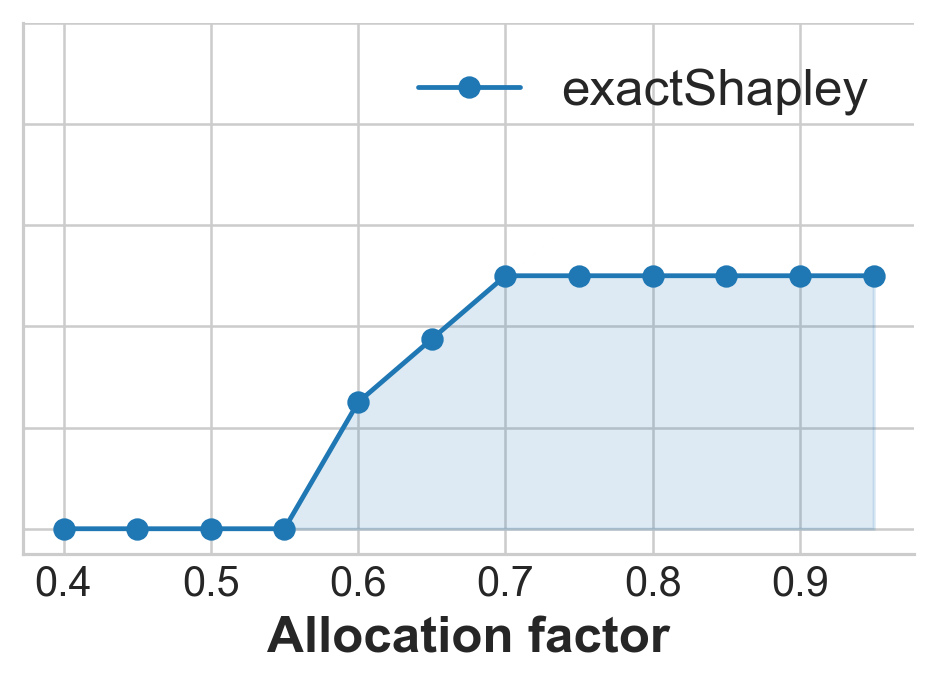

Saved plot to /Users/xander/Library/CloudStorage/OneDrive-Personal/KU Leuven/mid-term_pre/graphs/instance_1_pen0.01_method_exactShapley_alloc_collab.png
Plotting instance 1, penalty=0.01, method=proportional


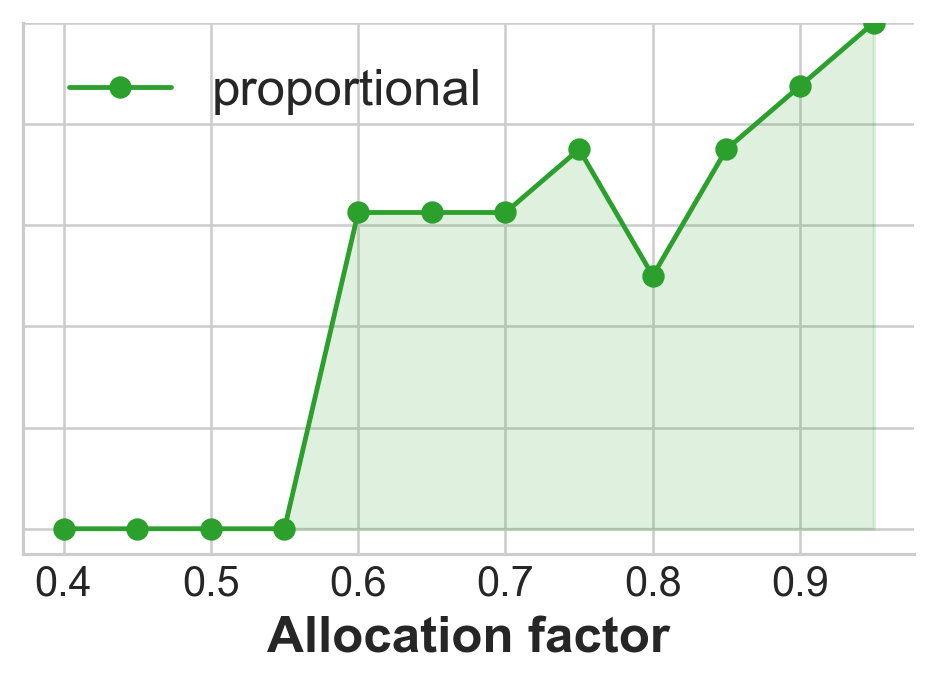

Saved plot to /Users/xander/Library/CloudStorage/OneDrive-Personal/KU Leuven/mid-term_pre/graphs/instance_1_pen0.01_method_proportional_alloc_collab.png
Plotting instance 1, penalty=0.01, method=approxShapStrat


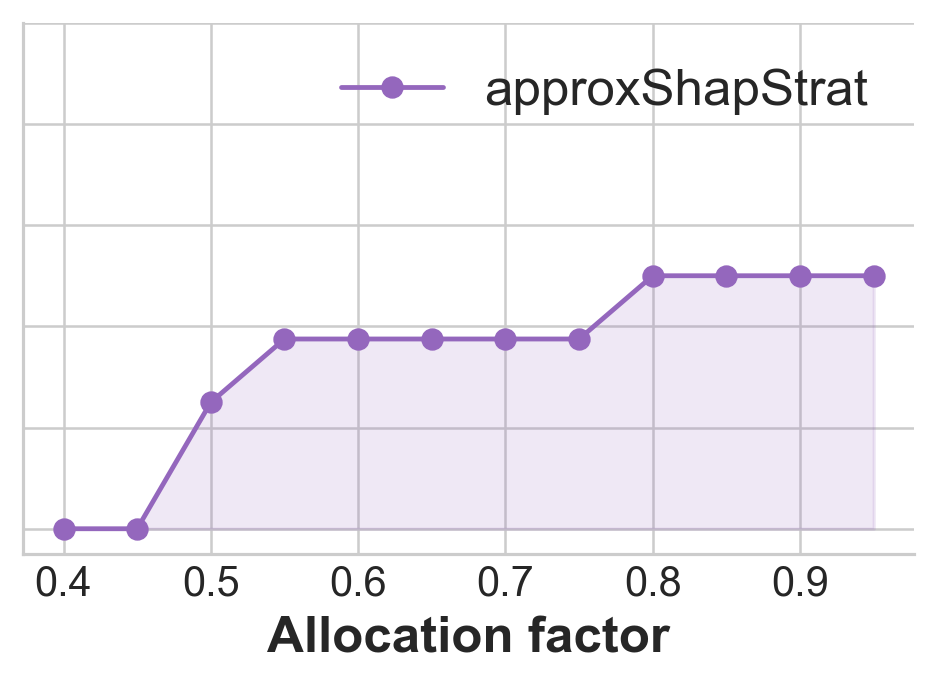

Saved plot to /Users/xander/Library/CloudStorage/OneDrive-Personal/KU Leuven/mid-term_pre/graphs/instance_1_pen0.01_method_approxShapStrat_alloc_collab.png
Plotting instance 1, penalty=0.01, method=marginal


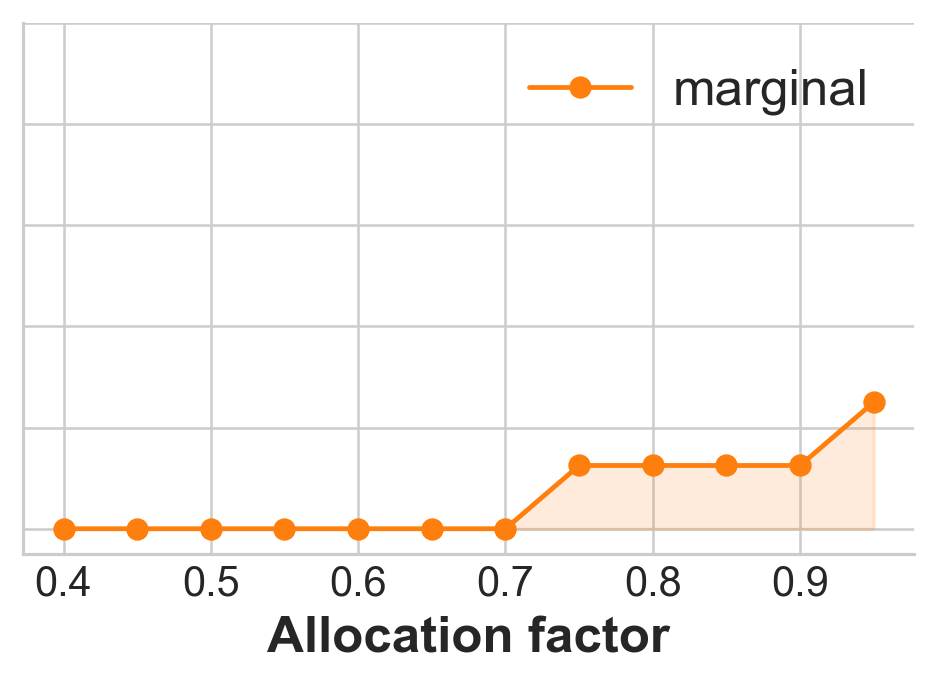

Saved plot to /Users/xander/Library/CloudStorage/OneDrive-Personal/KU Leuven/mid-term_pre/graphs/instance_1_pen0.01_method_marginal_alloc_collab.png
Plotting instance 1, penalty=0.01, method=approxShapMC


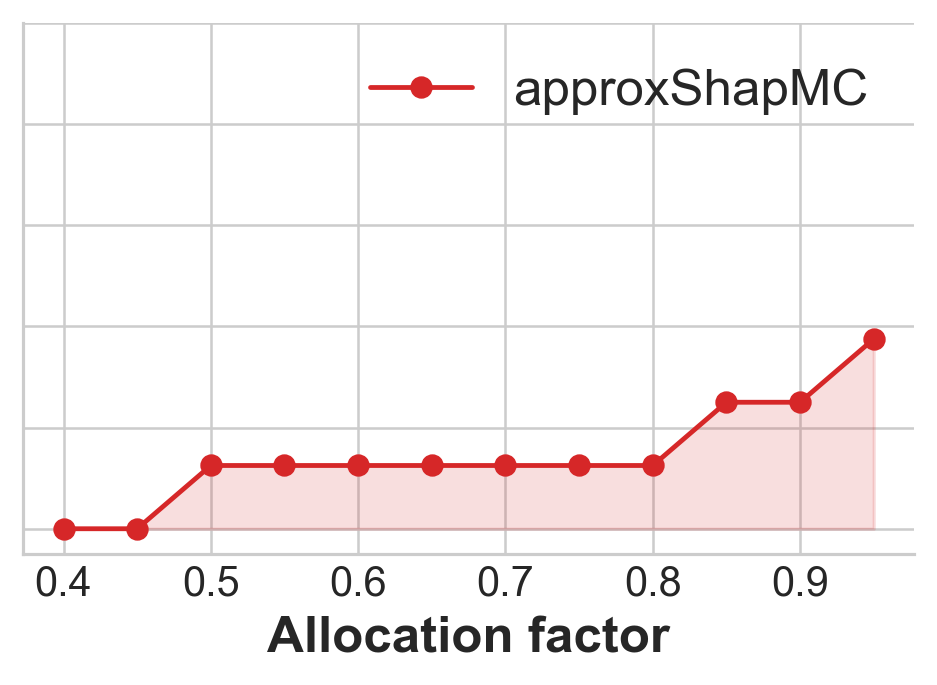

Saved plot to /Users/xander/Library/CloudStorage/OneDrive-Personal/KU Leuven/mid-term_pre/graphs/instance_1_pen0.01_method_approxShapMC_alloc_collab.png


In [73]:
plot_instance_alloc_collab(test_alloc_df, num_instance=1, 
                           output_path=r'/Users/xander/Library/CloudStorage/OneDrive-Personal/KU Leuven/mid-term_pre/graphs')

Plotting instance 1, penalty=0.01, method=exactShapley


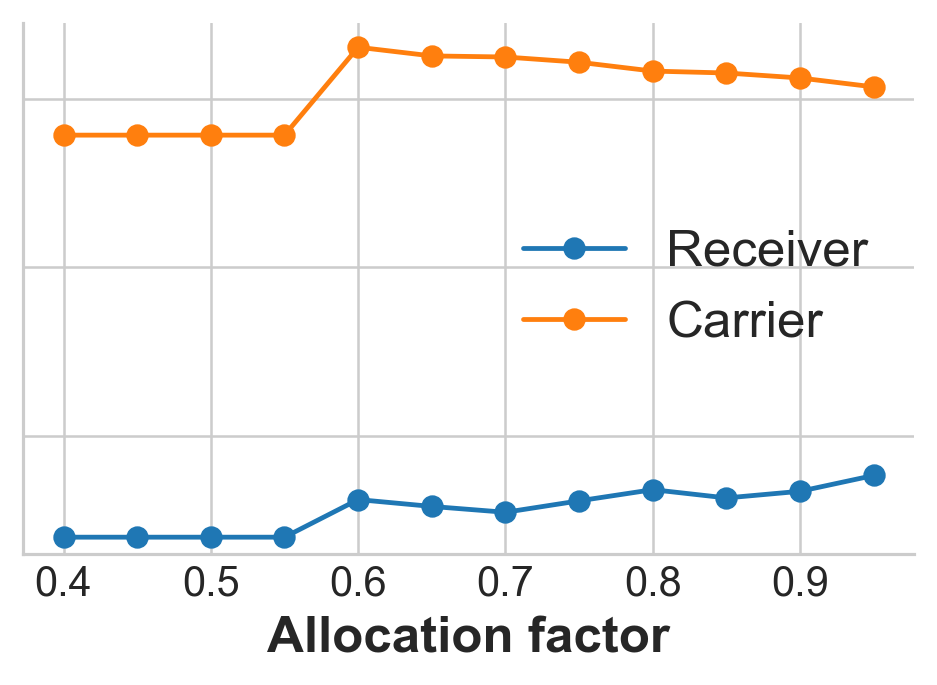

Saved plot to /Users/xander/Library/CloudStorage/OneDrive-Personal/KU Leuven/mid-term_pre/graphs/instance_1_pen0.01_method_exactShapley_alloc_scores.png
Plotting instance 1, penalty=0.01, method=proportional


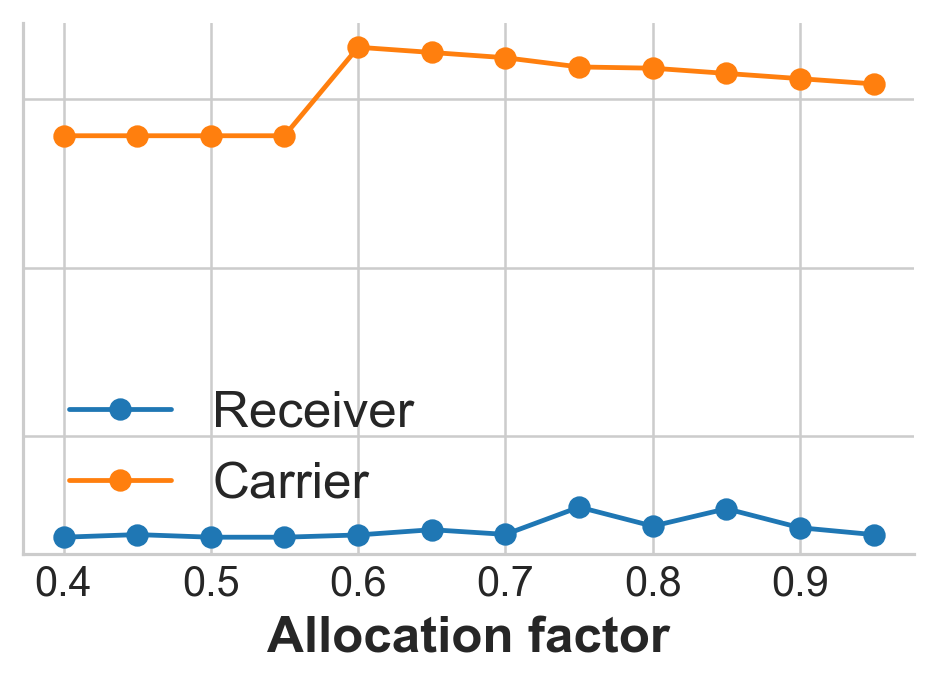

Saved plot to /Users/xander/Library/CloudStorage/OneDrive-Personal/KU Leuven/mid-term_pre/graphs/instance_1_pen0.01_method_proportional_alloc_scores.png
Plotting instance 1, penalty=0.01, method=approxShapStrat


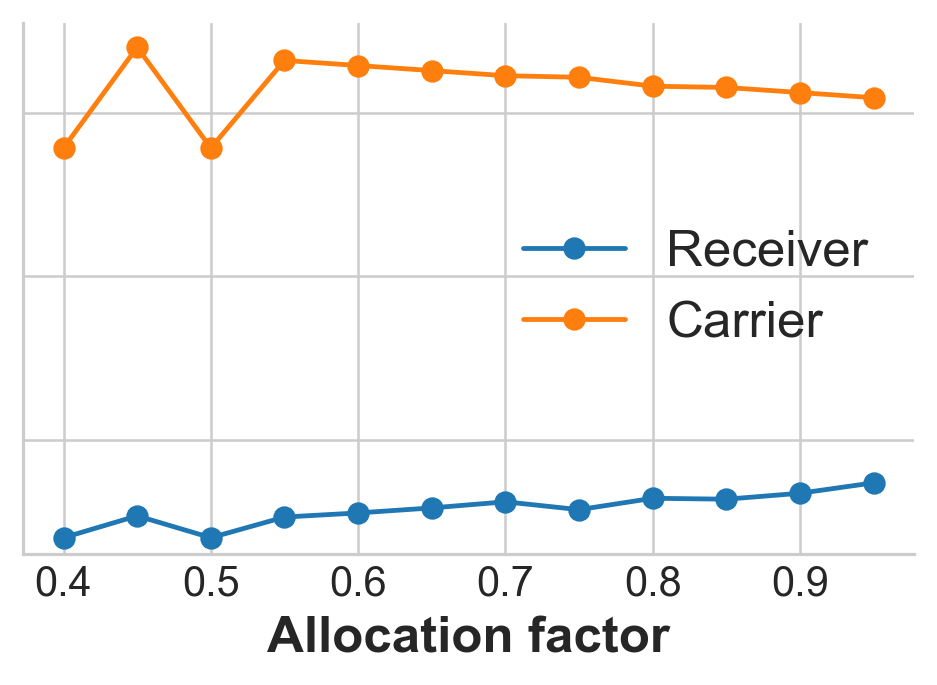

Saved plot to /Users/xander/Library/CloudStorage/OneDrive-Personal/KU Leuven/mid-term_pre/graphs/instance_1_pen0.01_method_approxShapStrat_alloc_scores.png
Plotting instance 1, penalty=0.01, method=marginal


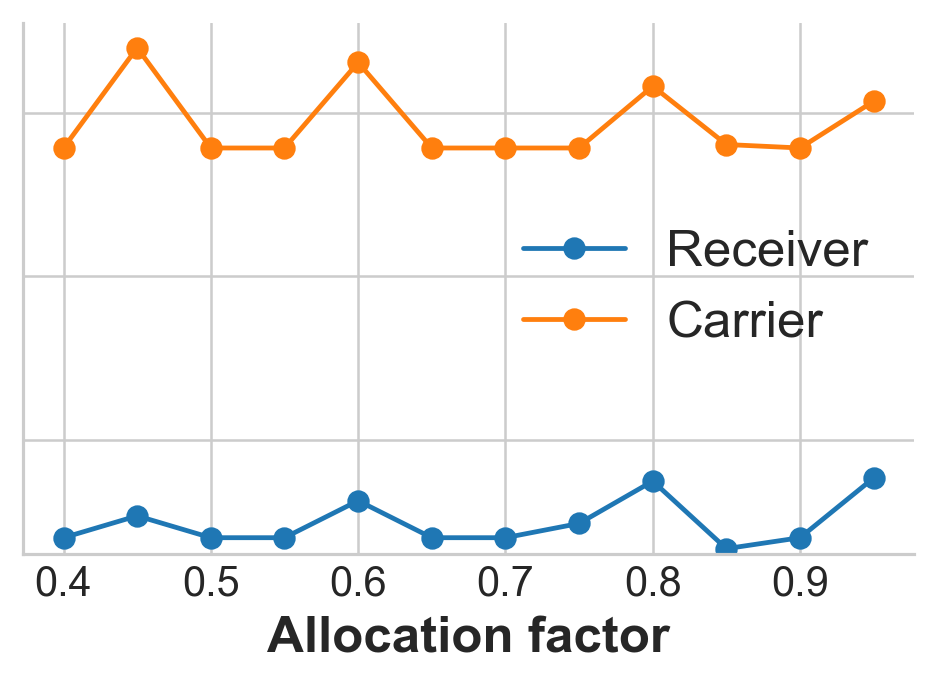

Saved plot to /Users/xander/Library/CloudStorage/OneDrive-Personal/KU Leuven/mid-term_pre/graphs/instance_1_pen0.01_method_marginal_alloc_scores.png
Plotting instance 1, penalty=0.01, method=approxShapMC


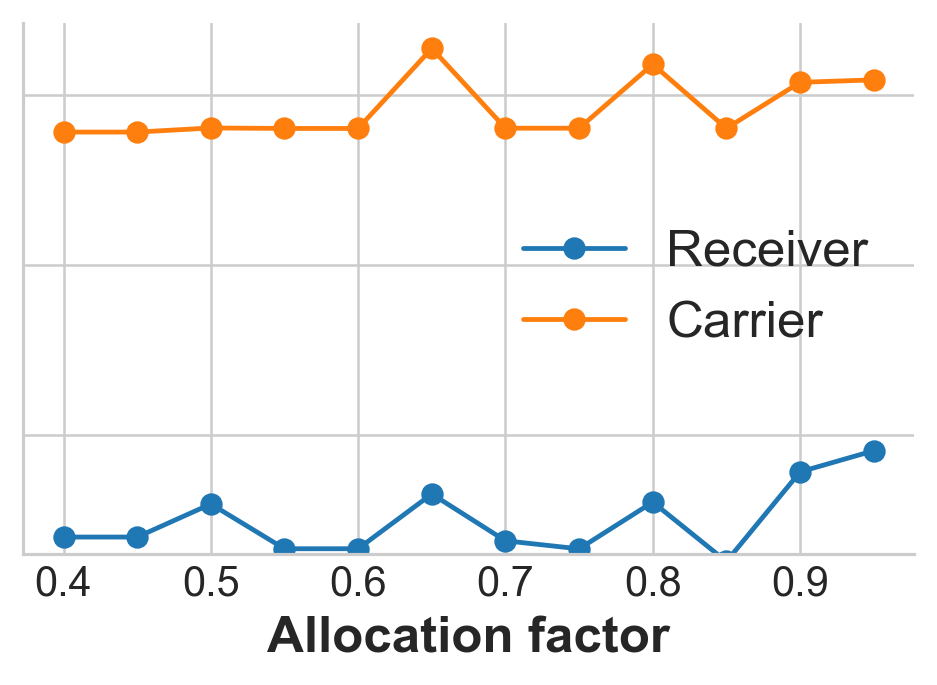

Saved plot to /Users/xander/Library/CloudStorage/OneDrive-Personal/KU Leuven/mid-term_pre/graphs/instance_1_pen0.01_method_approxShapMC_alloc_scores.png


In [82]:
plot_instance_alloc_scores(test_alloc_df, num_instance=1,
                           output_path=r'/Users/xander/Library/CloudStorage/OneDrive-Personal/KU Leuven/mid-term_pre/graphs')

## Test for penSweep

In [10]:
# Get the first subdirectory and construct path to receivers.xml.gz
subdir = os.listdir(results_dir)[0]
print(subdir)
receiver_file = os.path.join(results_dir, subdir, 'receivers.xml.gz')
count_collaborative_receivers(receiver_file)

penSweep-af0.60-p0.045-exactShapley-i00


{'collaborative_receivers': [],
 'non_collaborative_receivers': [{'id': 'collaborativeReceiver_0_to_1',
   'time_window': (6, 8),
   'time_window_str': '06:00:00 - 08:00:00',
   'score': -100.0},
  {'id': 'collaborativeReceiver_1_to_2',
   'time_window': (6, 8),
   'time_window_str': '06:00:00 - 08:00:00',
   'score': -100.0},
  {'id': 'collaborativeReceiver_2_to_3',
   'time_window': (6, 8),
   'time_window_str': '06:00:00 - 08:00:00',
   'score': -100.0},
  {'id': 'collaborativeReceiver_3_to_4',
   'time_window': (6, 8),
   'time_window_str': '06:00:00 - 08:00:00',
   'score': -100.0},
  {'id': 'collaborativeReceiver_4_to_5',
   'time_window': (6, 8),
   'time_window_str': '06:00:00 - 08:00:00',
   'score': -100.0},
  {'id': 'collaborativeReceiver_5_to_6',
   'time_window': (6, 8),
   'time_window_str': '06:00:00 - 08:00:00',
   'score': -100.0},
  {'id': 'collaborativeReceiver_6_to_7',
   'time_window': (6, 8),
   'time_window_str': '06:00:00 - 08:00:00',
   'score': -100.0},
  {'id

In [43]:
test_df = convert_results_to_dataframe(results_dir, include_receiver_stats=True)
test_df

,scenario_type,af,penalty,method,instance,run_dir,folder_name,collab_receivers,non_collab_receivers,total_receivers,receiver_total_score,carrier_total_score
0,penSweep,0.60,0.035,approxShapMC,1,H:/carrierReciverCollabResults\penSweep-af0.60...,penSweep-af0.60-p0.035-approxShapMC-i01,0,8,8,-800.000000,392.142607
1,penSweep,0.75,0.003,approxShapStrat,0,H:/carrierReciverCollabResults\penSweep-af0.75...,penSweep-af0.75-p0.003-approxShapStrat-i00,8,0,8,-633.259955,622.656078
2,penSweep,0.60,0.025,marginal,0,H:/carrierReciverCollabResults\penSweep-af0.60...,penSweep-af0.60-p0.025-marginal-i00,0,8,8,-800.000000,392.142607
3,penSweep,0.90,0.050,exactShapley,0,H:/carrierReciverCollabResults\penSweep-af0.90...,penSweep-af0.90-p0.050-exactShapley-i00,0,8,8,-800.000000,392.142607
4,penSweep,0.90,0.025,marginal,1,H:/carrierReciverCollabResults\penSweep-af0.90...,penSweep-af0.90-p0.025-marginal-i01,2,6,8,-704.780837,561.086560
...,...,...,...,...,...,...,...,...,...,...,...,...
369,penSweep,0.60,0.050,exactShapley,1,H:/carrierReciverCollabResults\penSweep-af0.60...,penSweep-af0.60-p0.050-exactShapley-i01,0,8,8,-800.000000,392.142607
370,penSweep,0.60,0.050,approxShapStrat,1,H:/carrierReciverCollabResults\penSweep-af0.60...,penSweep-af0.60-p0.050-approxShapStrat-i01,0,8,8,-800.000000,392.142607
371,penSweep,0.75,0.050,approxShapMC,1,H:/carrierReciverCollabResults\penSweep-af0.75...,penSweep-af0.75-p0.050-approxShapMC-i01,0,8,8,-800.000000,392.142607
372,penSweep,0.90,0.050,approxShapMC,1,H:/carrierReciverCollabResults\penSweep-af0.90...,penSweep-af0.90-p0.050-approxShapMC-i01,0,8,8,-800.000000,392.142607


In [57]:
test_df.query("instance == 1 and method=='approxShapMC' and af==0.6 and penalty==0.00")

,scenario_type,af,penalty,method,instance,run_dir,folder_name,collab_receivers,non_collab_receivers,total_receivers,receiver_total_score,carrier_total_score
9,penSweep,0.6,0.0,approxShapMC,1,H:/carrierReciverCollabResults\penSweep-af0.60...,penSweep-af0.60-p0.000-approxShapMC-i01,8,0,8,-613.234666,654.944892


Plotting instance 1, AF=0.6, method=approxShapMC


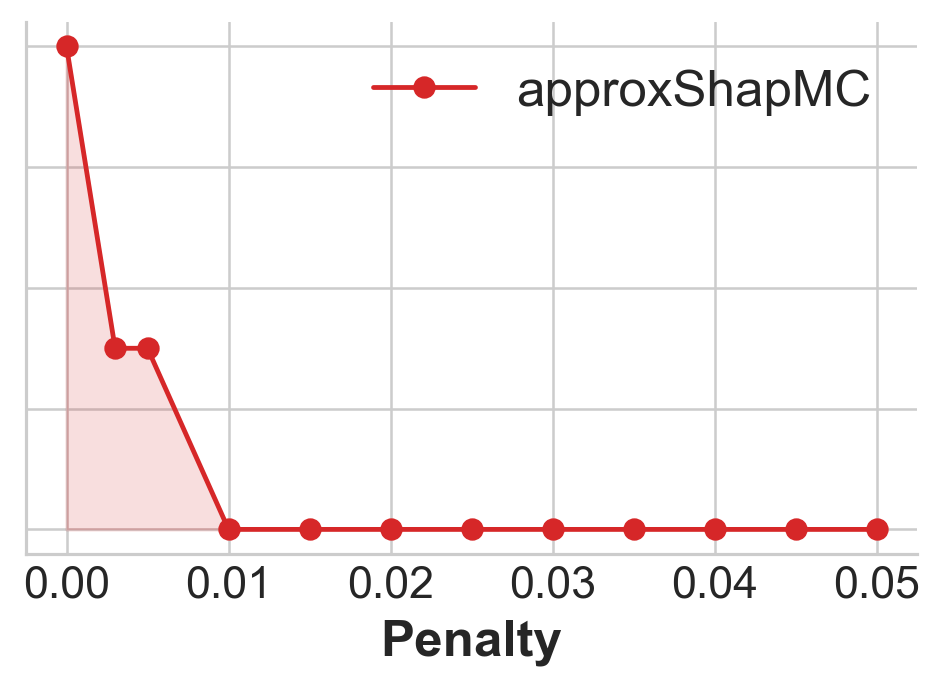

Plotting instance 1, AF=0.6, method=marginal


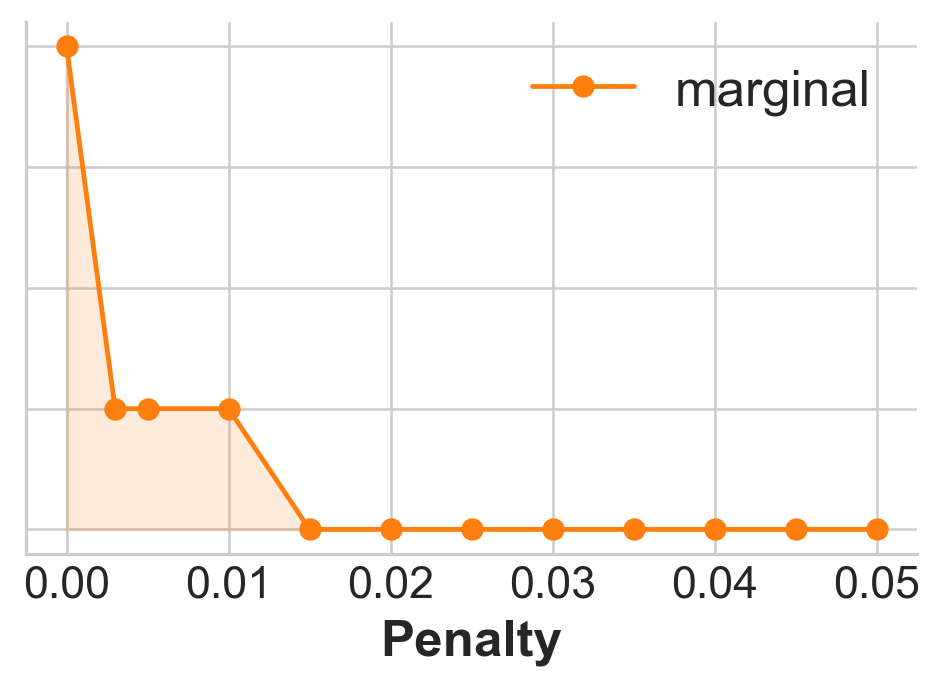

Plotting instance 1, AF=0.6, method=proportional


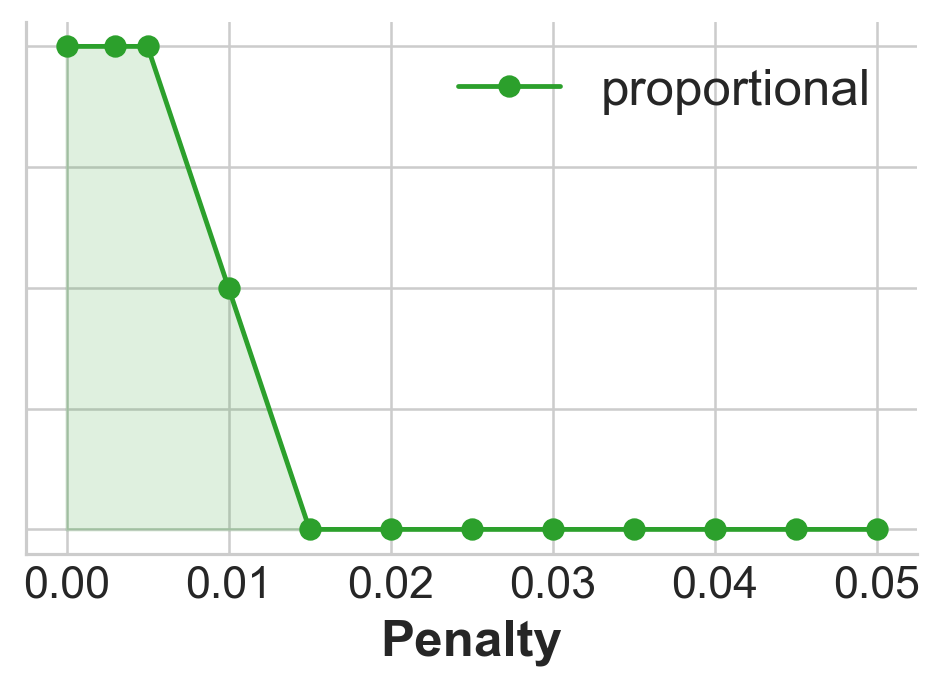

Plotting instance 1, AF=0.6, method=exactShapley


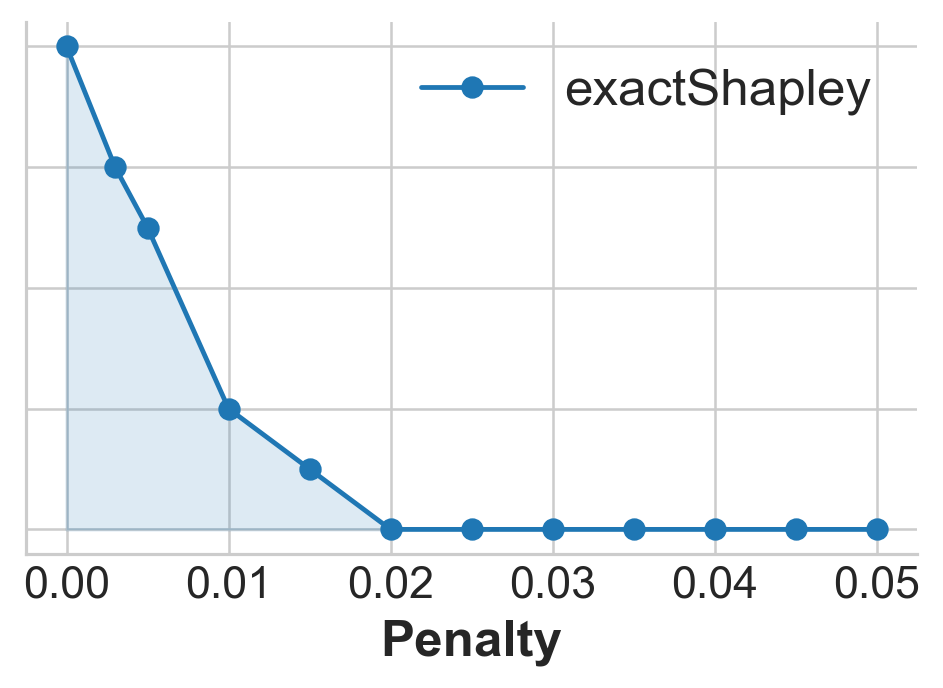

Plotting instance 1, AF=0.6, method=approxShapStrat


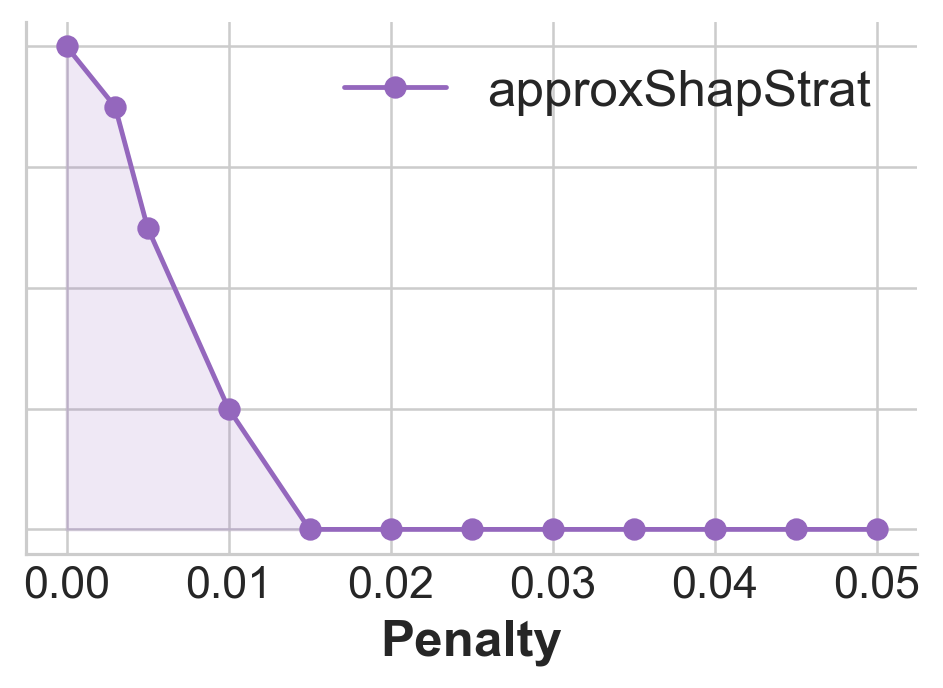

Plotting instance 1, AF=0.9, method=approxShapMC


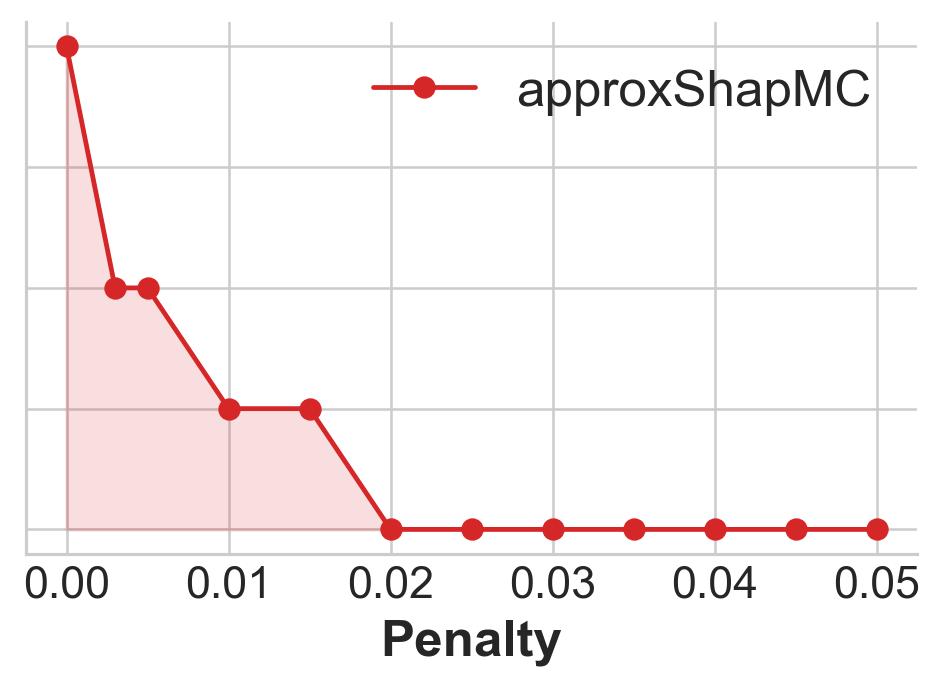

Plotting instance 1, AF=0.9, method=marginal


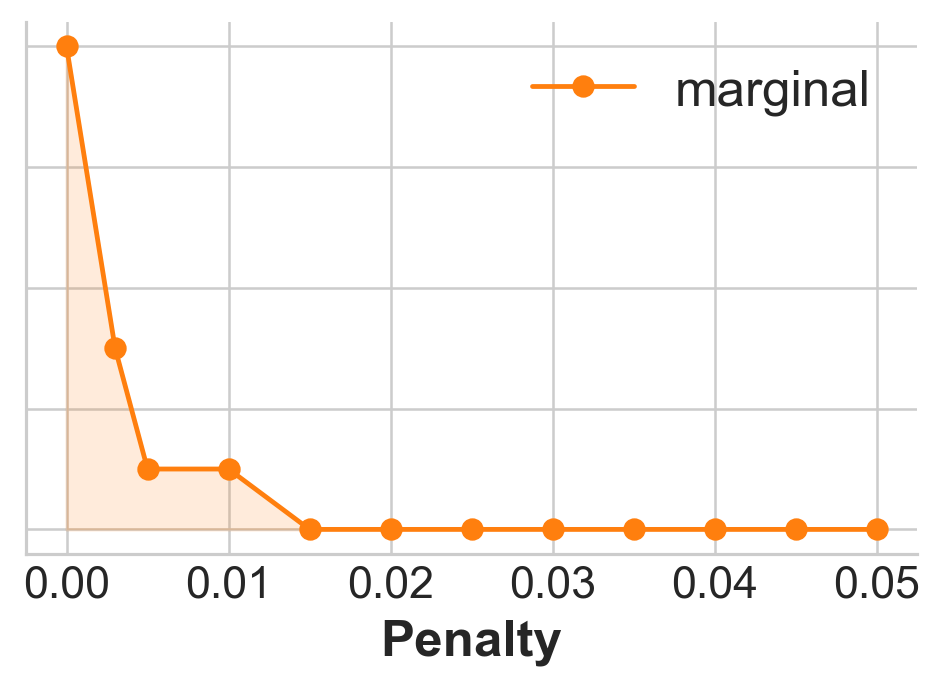

Plotting instance 1, AF=0.9, method=proportional


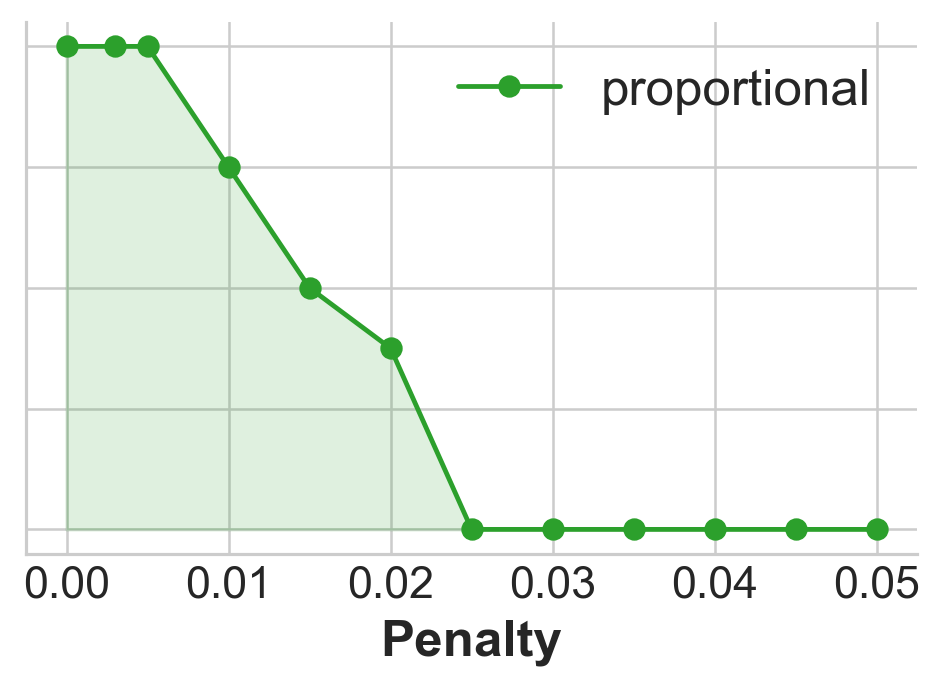

Plotting instance 1, AF=0.9, method=exactShapley


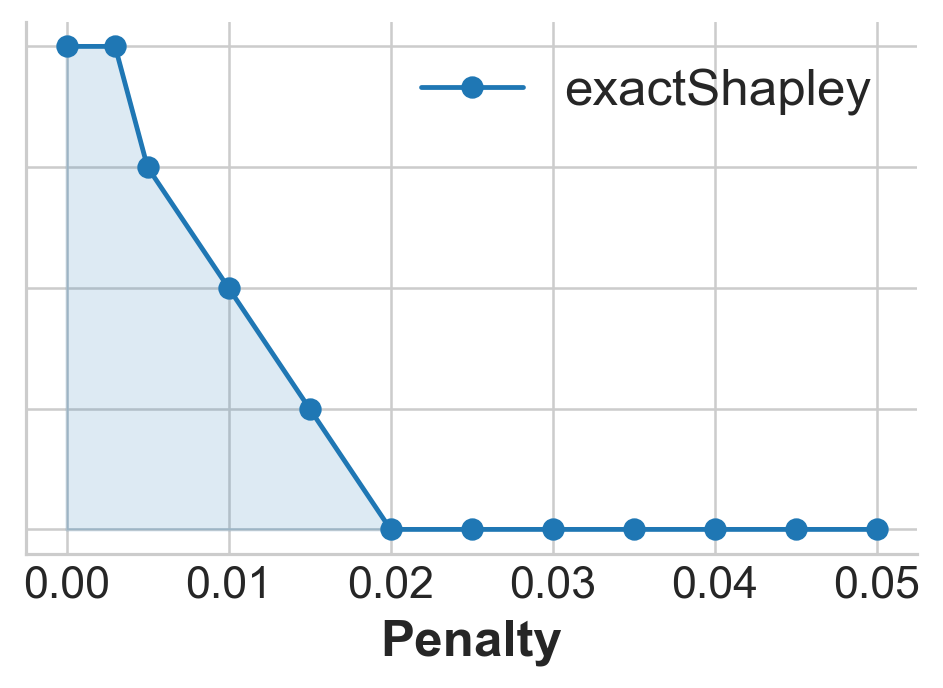

Plotting instance 1, AF=0.9, method=approxShapStrat


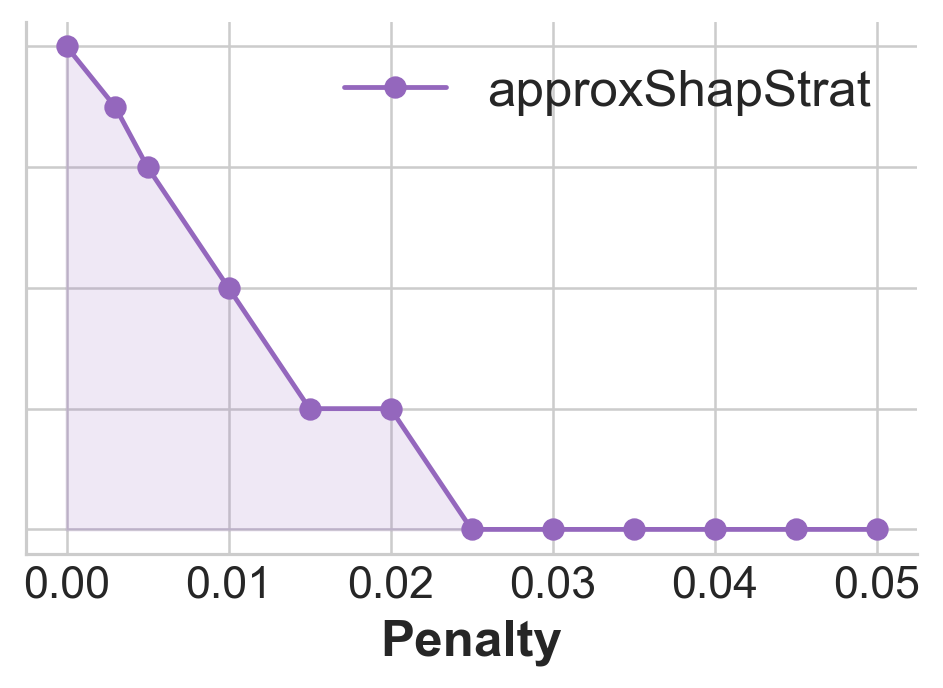

Plotting instance 1, AF=0.75, method=approxShapMC


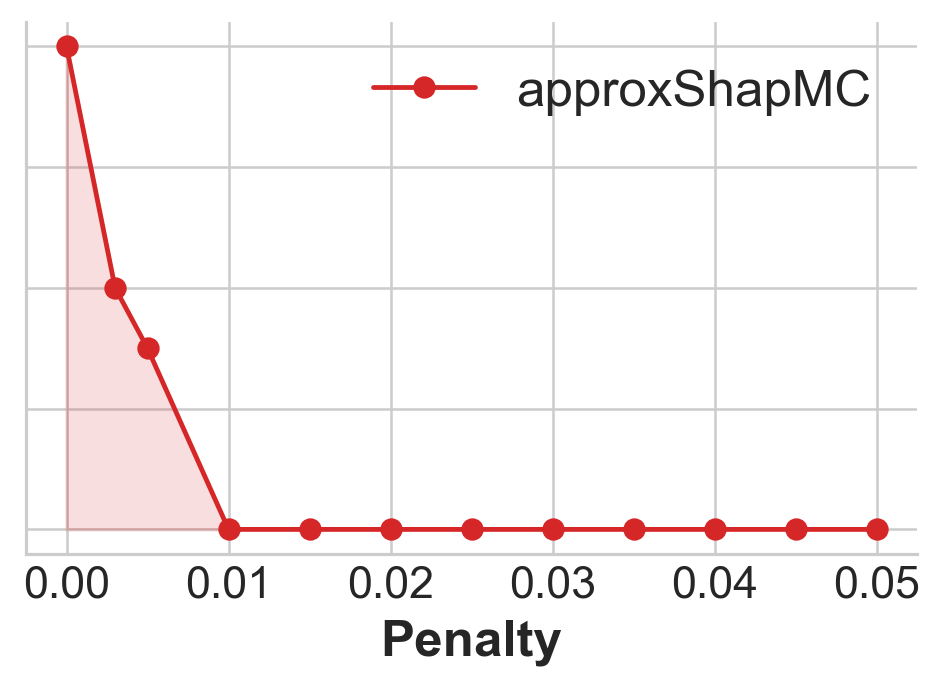

Plotting instance 1, AF=0.75, method=marginal


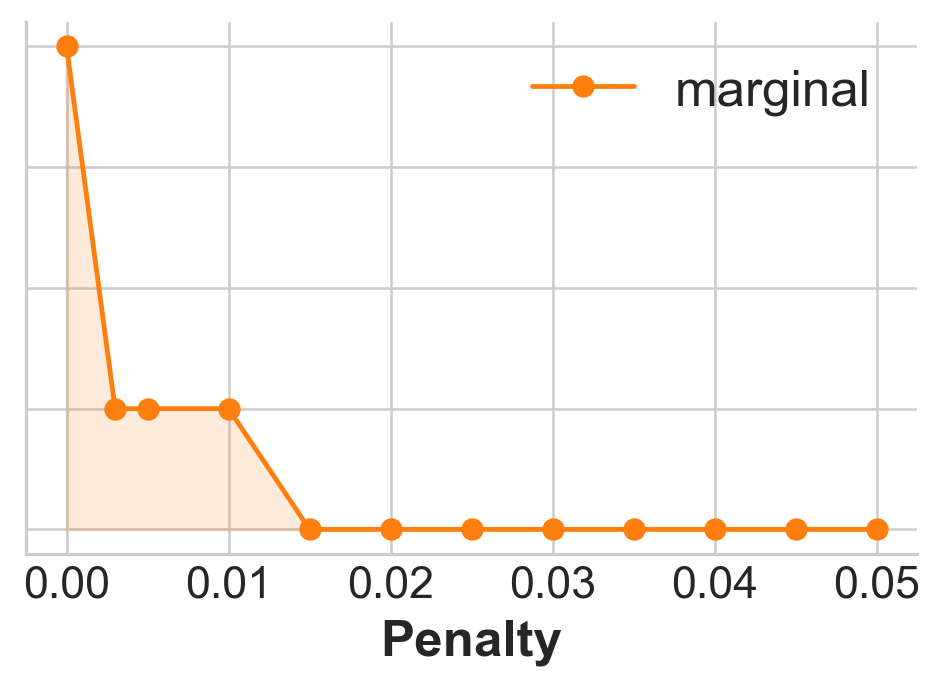

Plotting instance 1, AF=0.75, method=proportional


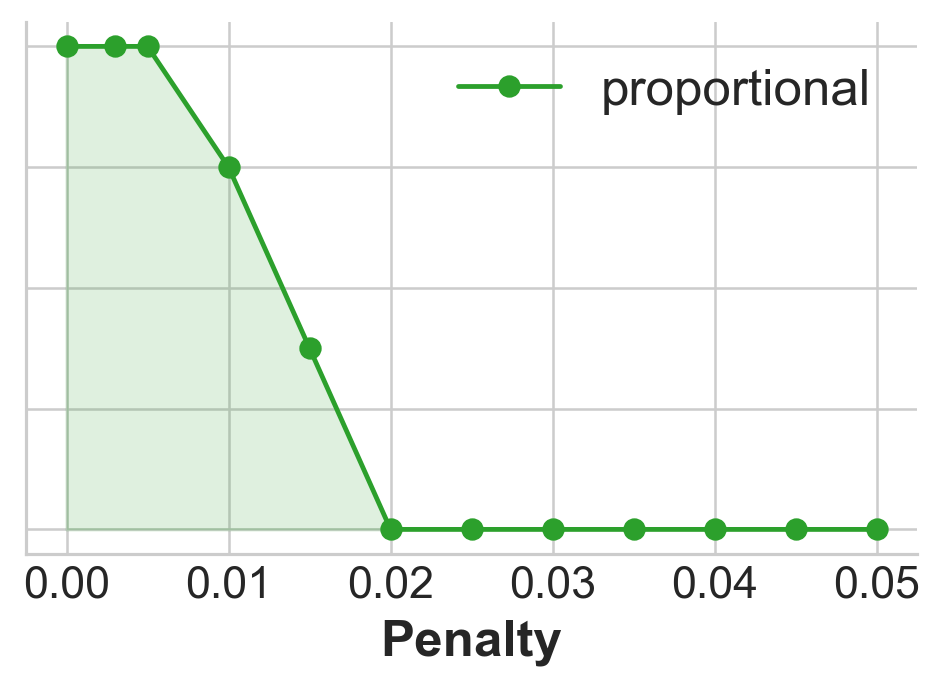

Plotting instance 1, AF=0.75, method=exactShapley


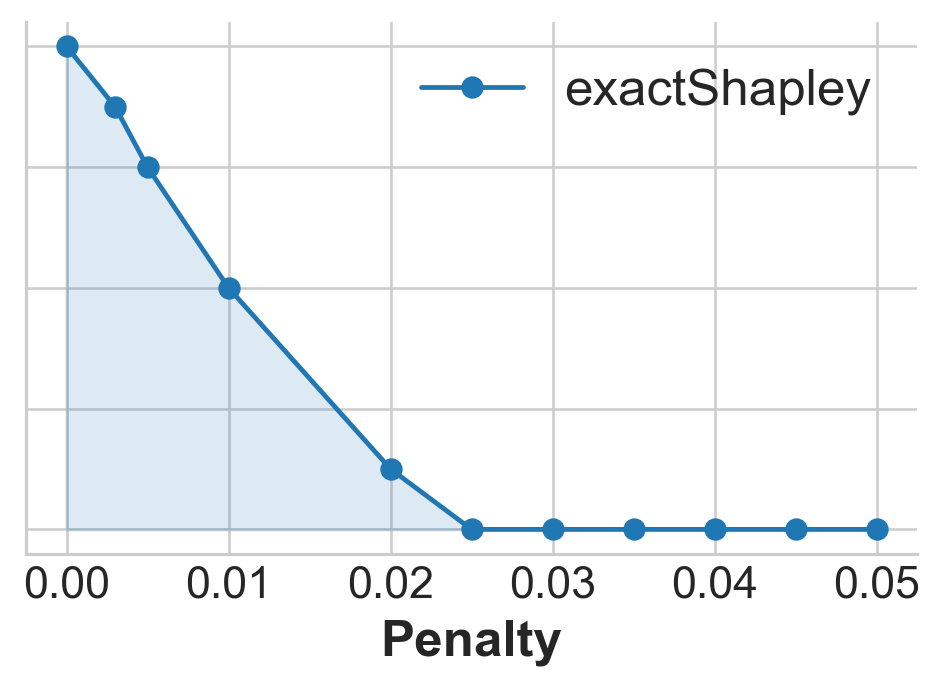

Plotting instance 1, AF=0.75, method=approxShapStrat


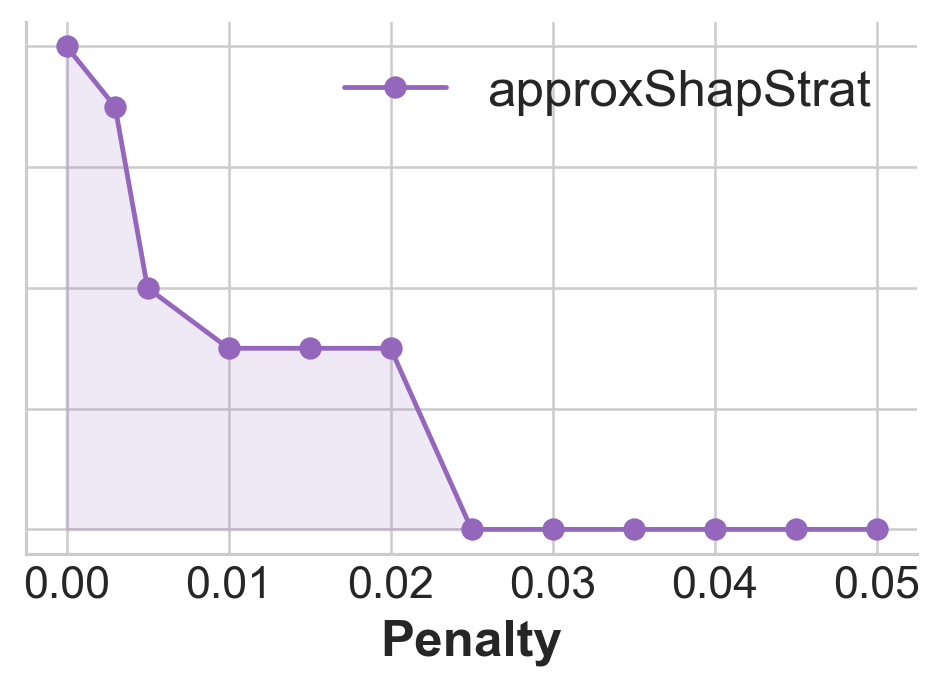

In [106]:
plot_instance_penalty_collab(test_df, 
                             num_instance=1,
                            #  output_path='F:\\OneDrive\\KU Leuven\\mid-term_pre\\graphs'
                             )